# Análise do challenge 004: posts, engajamento e patrocínio

Este notebook gera os números do laudo do dado (`../01_laudo_do_dado.md`). Cada seção diz o que está sendo conferido e por quê. Para rodar do zero, siga o README da submissão.

In [1]:
import sys
from pathlib import Path

PASTA_SOLUCAO = Path.cwd().resolve().parent  # o notebook roda dentro de solution/notebooks/
sys.path.insert(0, str(PASTA_SOLUCAO))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
from scipy import stats

from src.dados import carregar
from src.formato import numero_br, percentual_br
from src.laudo import indice_dispersao, proporcao_esperada_uniforme, usa_escrita_nao_latina, variacao_seguidores
from src.metricas import FAIXAS, LIMITES_FAIXA, adicionar_metricas

# Cores validadas para daltonismo e contraste sobre o fundo claro
AZUL, LARANJA = "#2a78d6", "#eb6834"
FUNDO, TINTA, TINTA_2, GRADE, EIXO = "#fcfcfb", "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "figure.facecolor": FUNDO, "axes.facecolor": FUNDO, "savefig.facecolor": FUNDO,
    "axes.edgecolor": EIXO, "axes.grid": True, "grid.color": GRADE, "grid.linewidth": 1,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "text.color": TINTA, "axes.labelcolor": TINTA_2, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "font.size": 10, "axes.titlesize": 11, "figure.dpi": 110,
})

bruto = carregar()
df = adicionar_metricas(bruto)
print(f"{numero_br(len(bruto))} posts e {bruto.shape[1]} colunas no CSV, "
      f"de {df['post_date'].min():%d/%m/%Y} a {df['post_date'].max():%d/%m/%Y}")

52.214 posts e 27 colunas no CSV, de 29/05/2023 a 28/05/2025


## 1. Laudo do dado

Antes de perguntar o que dá resultado, vale conferir se o arquivo consegue responder. São quatro testes simples (1.1 a 1.4). A seção 1.5 mostra que o método de análise acha efeitos quando eles existem.

### 1.1 Teste 1: cada métrica se comporta como um sorteio em torno de um valor fixo

Se um número é sorteado ao acaso em torno de uma média fixa (distribuição de Poisson), a variância fica igual à média e o **índice de dispersão** (variância dividida pela média) dá 1. Quando plataforma, formato, creator ou patrocínio mudam o resultado dos posts, as médias variam de um grupo para outro e o índice fica acima de 1. Índice igual a 1 quer dizer que nada além do sorteio explica a diferença entre um post e outro.

In [2]:
METRICAS = {"views": "views", "likes": "likes", "shares": "shares", "comentários": "comments_count"}
teste1 = pd.DataFrame(
    {
        nome: {
            "média": df[coluna].mean(),
            "desvio-padrão": df[coluna].std(),
            "raiz da média": np.sqrt(df[coluna].mean()),
            "mínimo": df[coluna].min(),
            "máximo": df[coluna].max(),
            "índice de dispersão": indice_dispersao(df[coluna]),
        }
        for nome, coluna in METRICAS.items()
    }
).T
(
    teste1.style.format(lambda v: numero_br(v, 2))
    .format(lambda v: numero_br(v, 0), subset=["mínimo", "máximo"])
    .format(lambda v: numero_br(v, 3), subset=["índice de dispersão"])
)

,média,desvio-padrão,raiz da média,mínimo,máximo,índice de dispersão
views,"10.100,28","100,03","100,50",9.676,10.551,"0,991"
likes,"1.510,27","38,92","38,86",1.354,1.668,"1,003"
shares,"300,02","17,31","17,32",227,380,"0,999"
comentários,"200,02","14,09","14,14",140,258,"0,993"


Quanto o índice poderia passar de 1 só por acaso? Com 52 mil posts, pouco. A conta abaixo usa essa folga para calcular a maior diferença possível entre grupos de posts, qualquer que seja o grupo (plataforma, formato, creator, patrocínio): é o desvio-padrão máximo das médias dos grupos, em relação à média geral.

In [3]:
folga = 1.96 * np.sqrt(2 / (len(df) - 1))  # variação do índice só por acaso, com 95% de confiança
teto = (teste1["índice de dispersão"] + folga - 1).clip(lower=0)
teste1["diferença máxima entre grupos"] = np.sqrt(teto * teste1["média"]) / teste1["média"]
(
    teste1[["índice de dispersão", "diferença máxima entre grupos"]].style
    .format(lambda v: numero_br(v, 3), subset=["índice de dispersão"])
    .format(lambda v: percentual_br(v, 2), subset=["diferença máxima entre grupos"])
)

,índice de dispersão,diferença máxima entre grupos
views,"0,991","0,05%"
likes,"1,003","0,32%"
shares,"0,999","0,60%"
comentários,"0,993","0,51%"


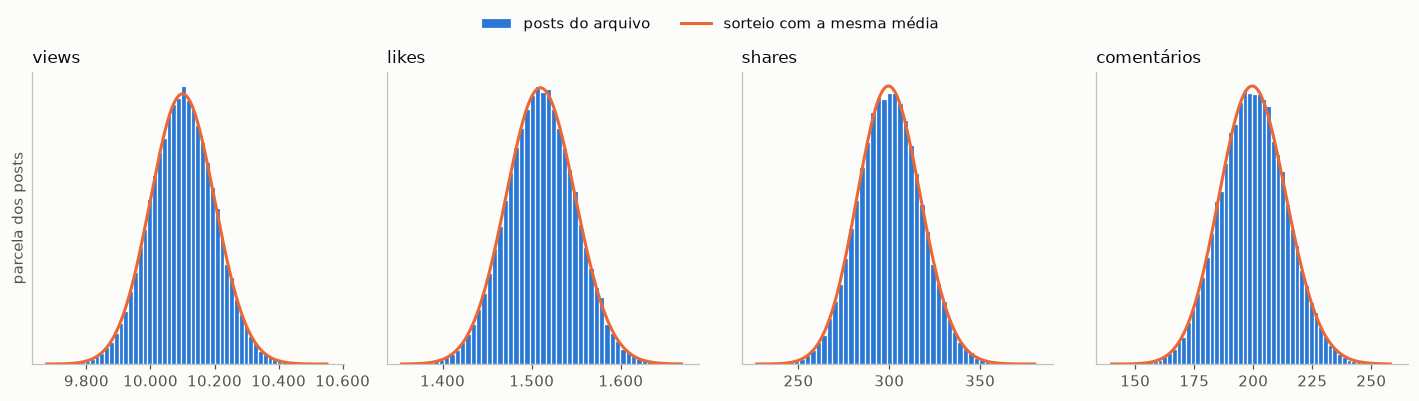

In [4]:
fig, eixos = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, (nome, coluna) in zip(eixos, METRICAS.items()):
    valores = df[coluna]
    largura = max(1, int(np.ceil((valores.max() - valores.min()) / 60)))
    bordas = np.arange(valores.min(), valores.max() + largura + 1, largura) - 0.5
    ax.hist(valores, bins=bordas, density=True, color=AZUL, edgecolor=FUNDO, linewidth=0.8, label="posts do arquivo")
    x = np.arange(valores.min(), valores.max() + 1)
    ax.plot(x, stats.poisson.pmf(x, valores.mean()), color=LARANJA, linewidth=2, label="sorteio com a mesma média")
    ax.set_title(nome, loc="left")
    ax.set_yticks([])
    ax.grid(axis="x", visible=False)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: numero_br(v)))
eixos[0].set_ylabel("parcela dos posts")
fig.legend(*eixos[0].get_legend_handles_labels(), loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.show()

### 1.2 Teste 2: o mesmo creator aparece com números de seguidores muito diferentes

O número de seguidores de um creator muda devagar: de um post para o seguinte, a diferença costuma ser pequena. Se cada post traz um número sem relação com o anterior, a faixa do creator (nano, micro, mid, macro) não é confiável, e comparar resultados por faixa perde o sentido.

In [5]:
seguidores = variacao_seguidores(df)
posts_por_creator = df.groupby("creator_id").size()
print(f"{numero_br(len(seguidores))} creators, cada um com {posts_por_creator.min()} a {posts_por_creator.max()} posts")
print(f"Creators com número de seguidores diferente entre os próprios posts: {percentual_br((seguidores['razao'] > 1).mean(), 1)}")
print(f"Maior número dividido pelo menor, no mesmo creator (mediana entre creators): {numero_br(seguidores['razao'].median(), 1)} vezes")

5.000 creators, cada um com 10 a 11 posts
Creators com número de seguidores diferente entre os próprios posts: 100,0%
Maior número dividido pelo menor, no mesmo creator (mediana entre creators): 13,8 vezes


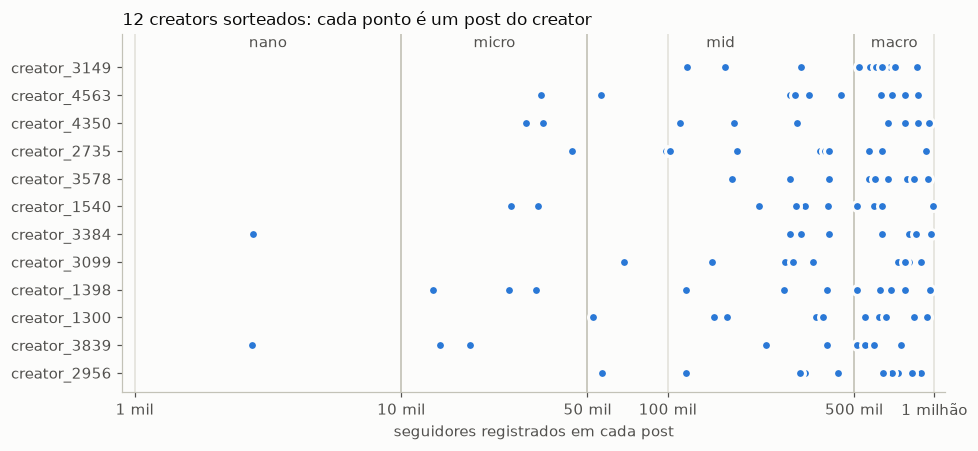

In [6]:
amostra = seguidores.sample(12, random_state=4).index
fig, ax = plt.subplots(figsize=(9, 4.2))
for i, creator in enumerate(amostra):
    valores = df.loc[df["creator_id"] == creator, "follower_count"]
    ax.scatter(valores, np.full(len(valores), i), s=42, color=AZUL, edgecolors=FUNDO, linewidths=2, zorder=3)
ax.set_xscale("log")
ax.minorticks_off()
for limite in LIMITES_FAIXA[1:-1]:
    ax.axvline(limite, color=EIXO, linewidth=1, zorder=1)
for inicio, fim, faixa in zip(LIMITES_FAIXA[:-1], LIMITES_FAIXA[1:], FAIXAS):
    centro = np.sqrt(max(inicio, 1_000) * min(fim, 1_000_000))
    ax.text(centro, len(amostra) - 0.4, faixa, ha="center", va="bottom", color=TINTA_2)
ax.set_xlim(900, 1_100_000)
ax.set_xticks([1_000, 10_000, 50_000, 100_000, 500_000, 1_000_000], ["1 mil", "10 mil", "50 mil", "100 mil", "500 mil", "1 milhão"])
ax.set_yticks(range(len(amostra)), amostra)
ax.set_ylim(-0.7, len(amostra) + 0.2)
ax.grid(axis="y", visible=False)
ax.set_xlabel("seguidores registrados em cada post")
ax.set_title("12 creators sorteados: cada ponto é um post do creator", loc="left")
plt.tight_layout()
plt.show()

Se o número de seguidores fosse sorteado por igual entre o menor e o maior valor do arquivo, quantos posts cairiam em cada faixa? A tabela compara essa conta com o arquivo.

In [7]:
esperado = proporcao_esperada_uniforme(LIMITES_FAIXA, df["follower_count"].min(), df["follower_count"].max())
teste2 = pd.DataFrame(
    {
        "posts": df["faixa_creator"].value_counts().reindex(FAIXAS),
        "parcela no arquivo": df["faixa_creator"].value_counts(normalize=True).reindex(FAIXAS),
        "parcela se fosse sorteio": esperado,
    }
)
(
    teste2.style.format(lambda v: percentual_br(v, 1))
    .format(lambda v: numero_br(v), subset=["posts"])
)

,posts,parcela no arquivo,parcela se fosse sorteio
faixa_creator,,,
nano,454,"0,9%","0,9%"
micro,2.110,"4,0%","4,0%"
mid,23.621,"45,2%","45,0%"
macro,26.029,"49,9%","50,1%"


In [8]:
print(f"Correlação entre seguidores e views: {numero_br(df['follower_count'].corr(df['views']), 3)} "
      "(0 = nenhuma relação; 1 = relação perfeita)")
por_faixa = df.groupby("faixa_creator", observed=True).agg(
    posts=("views", "size"), views_media=("views", "mean"), engajamento_medio=("engajamento", "mean")
)
(
    por_faixa.style.format(lambda v: numero_br(v), subset=["posts"])
    .format(lambda v: numero_br(v, 1), subset=["views_media"])
    .format(lambda v: numero_br(v, 4), subset=["engajamento_medio"])
)

Correlação entre seguidores e views: 0,005 (0 = nenhuma relação; 1 = relação perfeita)


,posts,views_media,engajamento_medio
faixa_creator,,,
nano,454,"10.090,6","0,1990"
micro,2.110,"10.101,3","0,1991"
mid,23.621,"10.099,5","0,1991"
macro,26.029,"10.101,1","0,1990"


### 1.3 Teste 3: as proporções são redondas demais e a alocação parece sorteada

Uma operação real não posta exatamente 60% em vídeo nem divide o público em 40% homens e 40% mulheres. Proporções redondas assim saem de um gerador configurado com percentuais fixos. O mesmo vale para a escolha do patrocinador: se ela dependesse do conteúdo, a mistura de categorias mudaria de um patrocinador para outro.

In [9]:
patrocinados = df[df["is_sponsored"]]
COLUNAS = {
    "plataforma": (df, "platform"), "formato": (df, "content_type"), "categoria": (df, "content_category"),
    "idioma": (df, "language"), "faixa etária do público": (df, "audience_age_distribution"),
    "gênero do público": (df, "audience_gender_distribution"), "país do público": (df, "audience_location"),
    "patrocinado": (df, "is_sponsored"), "categoria do patrocinador*": (patrocinados, "sponsor_category"),
    "tipo de divulgação*": (patrocinados, "disclosure_type"), "local da divulgação*": (patrocinados, "disclosure_location"),
}
for nome, (base, coluna) in COLUNAS.items():
    parcelas = base[coluna].value_counts(normalize=True)
    print(f"{nome:28s}" + " · ".join(f"{valor} {percentual_br(parcela, 1)}" for valor, parcela in parcelas.items()))
print("* só entre os posts patrocinados")

plataforma                  Bilibili 20,3% · YouTube 20,1% · Instagram 20,0% · RedNote 19,9% · TikTok 19,7%
formato                     video 60,3% · image 19,7% · mixed 10,0% · text 10,0%
categoria                   beauty 40,3% · lifestyle 39,8% · tech 20,0%
idioma                      English 50,0% · Chinese 20,0% · Hindi 10,1% · Spanish 10,0% · Japanese 9,9%
faixa etária do público     19-25 35,0% · 26-35 30,1% · 13-18 15,0% · 36-50 14,8% · 50+ 5,1%
gênero do público           male 40,2% · female 39,7% · non-binary 10,1% · unknown 10,0%
país do público             China 12,7% · UK 12,6% · Japan 12,6% · Brazil 12,5% · USA 12,4% · Germany 12,4% · India 12,4% · Russia 12,4%
patrocinado                 False 57,3% · True 42,7%
categoria do patrocinador*  food 17,2% · electronics 16,8% · fashion 16,6% · cosmetics 16,5% · gaming 16,5% · travel 16,3%
tipo de divulgação*         explicit 52,8% · implicit 47,2%
local da divulgação*        caption 40,1% · video 32,5% · hashtags 27,4%
* só en

In [10]:
contagem = pd.crosstab(patrocinados["sponsor_category"], patrocinados["content_category"])
qui2 = stats.chi2_contingency(contagem)
print(f"Teste de independência (qui-quadrado): p = {numero_br(qui2.pvalue, 2)}. "
      "p alto: nenhuma evidência de que a categoria do conteúdo dependa do patrocinador.")
contagem.div(contagem.sum(axis=1), axis=0).style.format(lambda v: percentual_br(v, 1))

Teste de independência (qui-quadrado): p = 0,70. p alto: nenhuma evidência de que a categoria do conteúdo dependa do patrocinador.


content_category,beauty,lifestyle,tech
sponsor_category,,,
cosmetics,"40,8%","39,6%","19,6%"
electronics,"39,0%","40,7%","20,3%"
fashion,"39,6%","39,5%","20,9%"
food,"39,8%","40,6%","19,6%"
gaming,"40,7%","39,6%","19,8%"
travel,"40,2%","39,0%","20,8%"


In [11]:
p_patrocinio = df["is_sponsored"].mean()
nunca = int((~df.groupby("creator_id")["is_sponsored"].any()).sum())
esperado_nunca = ((1 - p_patrocinio) ** posts_por_creator).sum()
print(f"Creators sem nenhum post patrocinado: {nunca} de {numero_br(len(posts_por_creator))}. "
      f"Se o patrocínio fosse sorteado post a post, o esperado seria {numero_br(esperado_nunca)}.")

Creators sem nenhum post patrocinado: 21 de 5.000. Se o patrocínio fosse sorteado post a post, o esperado seria 15.


### 1.4 Teste 4: os textos não fazem sentido

As descrições, os comentários e as hashtags parecem palavras em inglês sorteadas. Se o idioma do post fosse real, os posts marcados como chinês, japonês ou hindi teriam caracteres dessas línguas.

In [12]:
with pd.option_context("display.max_colwidth", 90):
    display(df.sample(4, random_state=1)[["language", "content_category", "content_description", "hashtags", "comments_text"]])

,language,content_category,content_description,hashtags,comments_text
47207,English,tech,Personal address produce affect young right those specific smile task usually Republic...,"go,music",Mr more ask vote bad fund order community. Performance pay factor control we system co...
27004,English,beauty,Summer I really environment debate stock full spend forward make whom market teach hou...,trial,Million baby purpose more recent.
44014,Spanish,tech,Leg eye behavior success become leave position note care anything drug control attenti...,"animal,fine",Another fund media economic.
8758,English,lifestyle,Budget half draw official small only garden decide billion task bit everybody several ...,"believe,move,quality",NaN


In [13]:
escrita = df.assign(tem_escrita_da_lingua=df["content_description"].map(usa_escrita_nao_latina))
por_idioma = (
    escrita.groupby("language")["tem_escrita_da_lingua"]
    .agg(posts="size", parcela_com_escrita_da_lingua="mean")
    .loc[["Chinese", "Japanese", "Hindi"]]
)
(
    por_idioma.style.format(lambda v: numero_br(v), subset=["posts"])
    .format(lambda v: percentual_br(v, 1), subset=["parcela_com_escrita_da_lingua"])
)

,posts,parcela_com_escrita_da_lingua
language,,
Chinese,10.428,"0,0%"
Japanese,5.177,"0,0%"
Hindi,5.272,"0,0%"


### 1.5 O método acha efeitos quando eles existem

Os testes acima dizem que o arquivo não tem diferenças entre grupos. Falta mostrar que isso não é defeito do método. O script `../validacao_metodo_simulacao.py` planta efeitos conhecidos (+15%, +10% e +3% no engajamento) em células sorteadas de uma cópia do dado e roda o mesmo método, 200 vezes para cada efeito. A tabela abaixo é a saída desse script. Nenhum número da análise vem da cópia com efeitos plantados.

- **taxa_sinal**: em quantas rodadas a célula plantada virou sinal.
- **taxa_abaixo_do_limiar**: em quantas o método percebeu a diferença, mas ela não passou de 10%.
- **falsos_positivos_por_rodada**: quantas outras células viraram sinal por engano, em média.

In [14]:
resumo_simulacao = pd.read_csv(PASTA_SOLUCAO / "resultados" / "validacao_metodo_resumo.csv")
(
    resumo_simulacao.style.hide(axis="index")
    .format(lambda v: percentual_br(v, 0, sinal=True), subset=["efeito"])
    .format(lambda v: percentual_br(v, 1), subset=["taxa_sinal", "taxa_abaixo_do_limiar"])
    .format(lambda v: percentual_br(v, 2, sinal=True), subset=["lift_medido_medio"])
    .format(lambda v: numero_br(v, 2), subset=["falsos_positivos_por_rodada"])
)

efeito,rodadas,taxa_sinal,taxa_abaixo_do_limiar,lift_medido_medio,falsos_positivos_por_rodada
+15%,200,"100,0%","0,0%","+15,04%","0,00"
+10%,200,"51,5%","48,5%","+10,02%","0,00"
+3%,200,"0,0%","99,5%","+3,01%","0,00"
